# 1D Domain Walls in `LambdaLLG`

This notebook collects three simple one-dimensional domain-wall examples:

1. relaxation from a Neel wall toward a Bloch wall,
2. field-driven annihilation of two domain walls, and
3. current-driven motion of a Bloch wall using spin-transfer torque.

The calculations below reuse the package seed painters and solver routines directly, so the main purpose of the notebook is to show how different physical terms change the wall profile and motion.

In [1]:
# Activate the package environment in the repository root.
using Pkg; Pkg.activate("../")

  Activating project at `C:\Users\freye\PersonalCode\LambdaLLG.jl`


In [2]:
# Load the 1D LLG tools and plotting backend used throughout the notebook.
using LambdaLLG

import PyPlot as plt

[ Info: Precompiling LambdaLLG [e49eaffb-1ff4-4058-b8bd-8b5ecf266929] (cache misses: include_dependency fsize change (2), mismatched flags (18))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## 1. Relaxing a Single Domain Wall

We begin with a single 1D wall in an easy-axis ferromagnet.
The first relaxation uses zero DMI, while the second turns on DMI to favor a different wall structure.

In the plots, the component colors follow the repository convention: blue for `m_x`, green for `m_y`, and red for `m_z`.

In [3]:
# Material and solver parameters for the single-wall example.
Nx = 100

J = 1.0
K = (0.0, 0.0, 0.2)
αG = 0.2
B_ext = (0.0, 0.0, 0.0)

# Build the 1D parameter object.
par = LLGParams1D(
    Nx,                    # Number of sites
    J,                     # Heisenberg exchange
    K,                     # Anisotropy vector
    B_ext,                 # External field
    αG                     # Gilbert damping
    );

### Initial Wall Seed

The initial state is built from a uniform `+z` background and then overwritten with a single wall.
Here the chosen wall normal gives a Neel-like starting texture.

In [4]:
# Start from a uniform chain and paint a single domain wall onto it.
s0_neel = uniform_seed1D(Nx) # Default direction is +z

paint_domain_wall1D!(s0_neel; wall_normal=(1,0,0))
normalize_spins!(s0_neel);

### Relaxation Without and With DMI

The wall is first relaxed with zero DMI to get a reference state.
After that, the DMI vector is changed and the already-relaxed wall is evolved again, producing a Bloch-like profile.

In [5]:
# Relax the seeded wall first without DMI and then with finite DMI.
t_relax = (0.0,200)

dmi = (0.0,0.0,0.0)
par.D = dmi

sol_neel = evolve1D(s0_neel, t_relax, par)

s_neel = reshape(sol_neel.u[end], 3, Nx)

dmi = (0.2,0.0,0.0)
par.D = dmi

sol_bloch = evolve1D(s_neel, t_relax, par)

s_bloch = reshape(sol_bloch.u[end], 3, Nx);

### Comparing the Profiles

The top panel compares the painted seed against the relaxed wall without DMI.
The bottom panel then compares that relaxed wall against the final state after DMI is turned on.

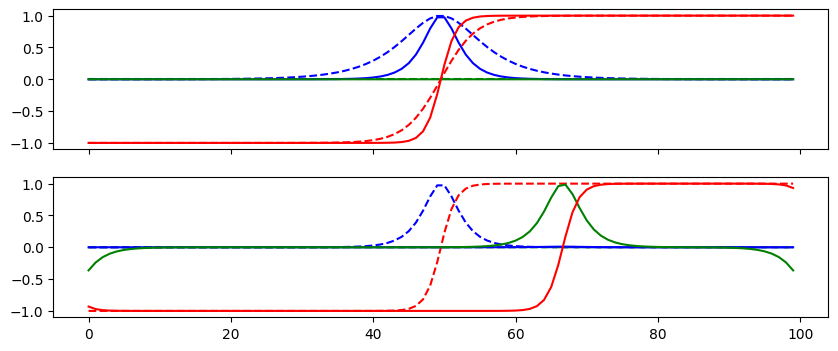

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x000001E487E674D0>

In [6]:
# Plot the initial wall, the relaxed Neel wall, and the DMI-driven Bloch wall.
fig, ax = plt.subplots(nrows=2, ncols=1, sharex="col", figsize=(10,4))

ax[1].plot(s0_neel[1,:], "b--")
ax[1].plot(s0_neel[2,:], "g--")
ax[1].plot(s0_neel[3,:], "r--")

ax[1].plot(s_neel[1,:], "b")
ax[1].plot(s_neel[2,:], "g")
ax[1].plot(s_neel[3,:], "r")

ax[2].plot(s_neel[1,:], "b--")
ax[2].plot(s_neel[2,:], "g--")
ax[2].plot(s_neel[3,:], "r--")

ax[2].plot(s_bloch[1,:], "b")
ax[2].plot(s_bloch[2,:], "g")
ax[2].plot(s_bloch[3,:], "r")

## 2. Field-Driven Domain Wall Annihilation

This example starts from a pair of domain walls.
After an initial relaxation, a field along `+z` is applied to drive the texture and eventually annihilate the walls.

In [7]:
# Parameters for the two-wall and field-driven annihilation example.
Nx = 150

J = 1.0
K = (0.0, 0.0, 0.2)
αG = 0.2
B_ext = (0.0, 0.0, 0.0)
dmi = (0.2, 0.0, 0.0)

# Build the 1D parameter object.
par = LLGParams1D(
    Nx,                    # Number of sites
    J,                     # Heisenberg exchange
    K,                     # Anisotropy vector
    B_ext,                 # External field
    αG;                    # Gilbert damping
    D = dmi
    );

### Two-Wall Seed

Two separate calls to `paint_domain_wall1D!` are used to place walls at different centers.
This produces a finite reversed domain between them.

In [8]:
# Paint two domain walls to create a finite reversed domain in the chain.
s0_2dw = uniform_seed1D(Nx) # Default direction is +z

paint_domain_wall1D!(s0_2dw; center=50, wall_normal=(0,1,0), 
    domain_direction=(0,0,-1), background_direction=(0,0,1))
paint_domain_wall1D!(s0_2dw; center=100, wall_normal=(0,1,0), 
    domain_direction=(0,0,1), background_direction=(0,0,-1))
normalize_spins!(s0_2dw);

### Relax, Then Turn on the Field

The texture is first relaxed at zero field.
Then the field is changed to `(0, 0, 1)` and the solver is run again to drive the walls together.
Two snapshots are saved: one halfway through the driven evolution and one at the end.

In [9]:
# Relax the two-wall state, then apply a field to drive annihilation.
t_relax = (0.0, 100)
t_drive = (0.0, 50)

sol_2dw = evolve1D(s0_2dw, t_relax, par)

s_2dw = reshape(sol_2dw.u[end], 3, Nx)

par.B = (0, 0, 1)

sol_ann = evolve1D(s_2dw, t_relax, par)

s_ann1 = reshape(sol_ann.u[end ÷ 2], 3, Nx)
s_ann2 = reshape(sol_ann.u[end], 3, Nx);

### Field-Driven Annihilation Plots

The first panel shows the painted two-wall seed against the relaxed configuration.
The second panel uses the relaxed profile in light gray as a reference, then overlays the intermediate and final driven states.

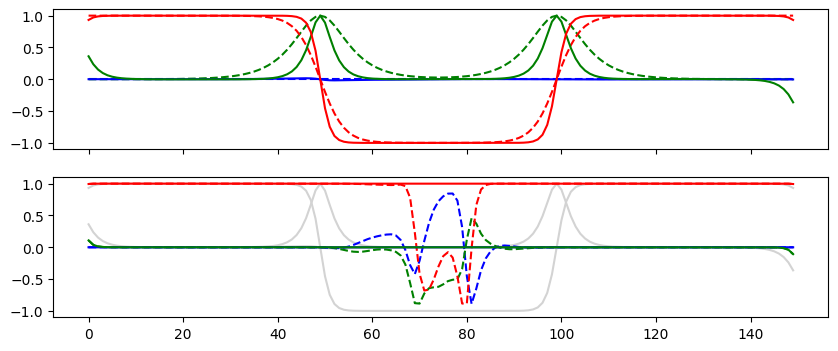

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x000001E479FAEB50>

In [10]:
# Compare the initial seed, the relaxed two-wall state, and the field-driven evolution.
fig, ax = plt.subplots(nrows=2, ncols=1, sharex="col", figsize=(10,4))

ax[1].plot(s0_2dw[1,:], "b--")
ax[1].plot(s0_2dw[2,:], "g--")
ax[1].plot(s0_2dw[3,:], "r--")

ax[1].plot(s_2dw[1,:], "b")
ax[1].plot(s_2dw[2,:], "g")
ax[1].plot(s_2dw[3,:], "r")

ax[2].plot(s_2dw[1,:], "lightgrey")
ax[2].plot(s_2dw[2,:], "lightgrey")
ax[2].plot(s_2dw[3,:], "lightgrey")

ax[2].plot(s_ann1[1,:], "b--")
ax[2].plot(s_ann1[2,:], "g--")
ax[2].plot(s_ann1[3,:], "r--")

ax[2].plot(s_ann2[1,:], "b")
ax[2].plot(s_ann2[2,:], "g")
ax[2].plot(s_ann2[3,:], "r")

## 3. STT-Driven Bloch Domain Wall

The last example prepares a Bloch wall and then turns on the optional Zhang-Li spin-transfer torque terms.
In addition to wall profiles, the notebook tracks the wall center as a function of time.

In [11]:
# Parameters for the current-driven Bloch wall example.
Nx = 100

J = 1.0
K = (0.0, 0.0, 0.2)
αG = 0.2
B_ext = (0.0, 0.0, 0.0)
dmi = (0.2, 0.0, 0.0)

# Build the 1D parameter object.
par = LLGParams1D(
    Nx,                    # Number of sites
    J,                     # Heisenberg exchange
    K,                     # Anisotropy vector
    B_ext,                 # External field
    αG;                    # Gilbert damping
    D = dmi
    );

### Bloch Wall Seed

As before, we start from a uniform chain and paint a wall.
This choice of wall normal prepares the Bloch-like initial state used for the STT run.

In [12]:
# Build a Bloch-like wall configuration and normalize it.
s0_bloch = uniform_seed1D(Nx) # Default direction is +z

paint_domain_wall1D!(s0_bloch; wall_normal=(0,1,0))

normalize_spins!(s0_bloch);

### Tracking the Wall Position

The next two definitions measure the wall center by locating the site where `m_z` is closest to zero.
That is a simple discrete proxy for the wall position during the driven evolution.

In [13]:
# Identify the site closest to the center of the wall and apply this to every saved state.
wall_center(mz) = argmin(abs.(mz))

function wall_centers(sol, Nx)
    return [wall_center(reshape(u, 3, Nx)[3, :]) for u in sol.u]
end

wall_centers (generic function with 1 method)

### Relax the Wall and Turn on STT

The Bloch wall is first relaxed with damping.
Then the STT parameters are set directly on the parameter object, including `par.stt_active = true`, before the driven solve.
As before, we keep both an intermediate and final snapshot.

In [14]:
# Relax the wall, enable STT, and track the driven motion.
t_relax = (0.0, 100)
t_drive = (0.0, 150)

sol_bloch = evolve1D(s0_bloch, t_relax, par)

s_bloch = reshape(sol_bloch.u[end], 3, Nx)

par.stt_active = true
par.u_stt = 0.2
par.beta_stt = 0.3

sol_stt = evolve1D(s_bloch, t_drive, par)

s_stt1 = reshape(sol_stt.u[end ÷ 2], 3, Nx)
s_stt2 = reshape(sol_stt.u[end], 3, Nx)

xdw = wall_centers(sol_stt, Nx);

### STT-Driven Motion Plots

The top panel compares the relaxed Bloch wall against two later profiles during STT-driven motion.
The bottom panel shows the wall-center coordinate extracted from the solver trajectory.

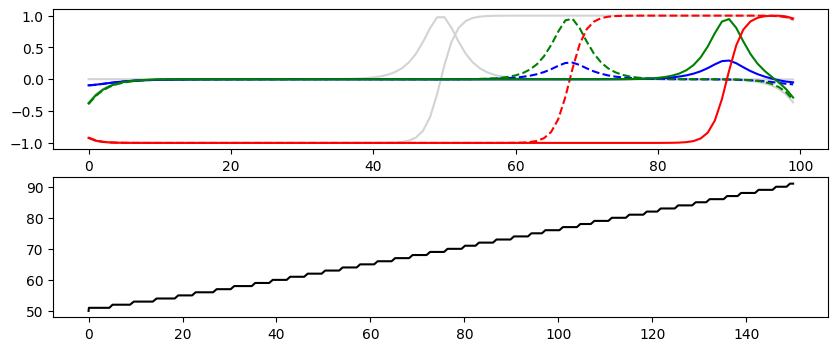

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x000001E487EA4E10>

In [15]:
# Plot the evolving wall profile and the extracted wall position over time.
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10,4))

ax[1].plot(s_bloch[1,:], "lightgrey")
ax[1].plot(s_bloch[2,:], "lightgrey")
ax[1].plot(s_bloch[3,:], "lightgrey")

ax[1].plot(s_stt1[1,:], "b--")
ax[1].plot(s_stt1[2,:], "g--")
ax[1].plot(s_stt1[3,:], "r--")

ax[1].plot(s_stt2[1,:], "b")
ax[1].plot(s_stt2[2,:], "g")
ax[1].plot(s_stt2[3,:], "r")

ax[2].plot(sol_stt.t, xdw, "k")

## Summary

These three examples show the same basic workflow with different driving terms:

- DMI changes the preferred internal structure of a single wall.
- A field can drive two walls together until the reversed domain disappears.
- Spin-transfer torque can translate a Bloch wall, which is easy to monitor through the extracted wall center.